# Composer Classification Using Deep Learning

## Introduction

Music is one of the most expressive forms of art, with each composer developing a distinctive style through melody, harmony, rhythm, tempo, and musical structure. Identifying the composer of an unfamiliar piece can be challenging, particularly for listeners without formal musical training. Advances in deep learning provide an opportunity to automatically learn these musical patterns and classify compositions based on their underlying characteristics.

The objective of this project is to develop a deep learning system capable of identifying the composer of a musical piece using its MIDI representation. The project focuses on compositions by Bach, Beethoven, Chopin, and Mozart and applies two deep learning architectures: Long Short-Term Memory (LSTM) networks and Convolutional Neural Networks (CNNs). These models will be used to recognize distinctive musical patterns and classify each composition according to its composer.

To accomplish this objective, the project follows a complete machine learning workflow that includes data collection, data preprocessing, data augmentation, feature extraction, model development, model training, evaluation, and optimization. Preparing the musical data in a structured and consistent format is essential so that the deep learning models can effectively learn meaningful relationships from the MIDI sequences.

This notebook presents the data preparation portion of the project. It includes dataset selection and exploration, MIDI file validation, train-validation-test splitting, data augmentation, feature extraction, composer label encoding, sequence normalization, and TensorFlow-compatible sequence preparation. The processed data produced in this notebook will be used as input for the LSTM and CNN models developed in the later stages of the project.

## Project Methodology

The complete team project follows these steps:

1. Data Collection
2. Data Preprocessing
3. Data Augmentation
4. Feature Extraction
5. Model Building
6. Model Training
7. Model Evaluation
8. Model Optimization

The dataset already contains MIDI files, so no conversion from another musical-score format is required. This notebook selects the four required composers, validates the MIDI files, extracts musical features, and prepares TensorFlow-compatible sequences.

The notebook ends after producing the processed datasets required for model development.

# 1. Environment Setup

This section installs and imports the libraries required for MIDI processing, numerical analysis, visualization, dataset splitting, and TensorFlow sequence preparation.

In [4]:
# Install the libraries required for MIDI processing and data preparation.

# !pip install pretty_midi tensorflow scikit-learn pandas numpy matplotlib

In [6]:
# Import standard Python libraries.
from pathlib import Path
from collections import defaultdict
import json
import warnings

# Import data-processing libraries.
import numpy as np
import pandas as pd

# Import the visualization library.
import matplotlib.pyplot as plt

# Import the MIDI-processing library.
import pretty_midi

# Import the dataset-splitting function.
from sklearn.model_selection import train_test_split

# Import TensorFlow and the Keras padding utility.
import tensorflow as tf
from tensorflow.keras.utils import pad_sequences

# Reduce unnecessary warning messages.
warnings.filterwarnings("ignore")

# Set random seeds to support reproducible results.
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Environment setup completed successfully.")

TensorFlow version: 2.16.1
NumPy version: 1.24.3
Pandas version: 2.2.3
Environment setup completed successfully.


# 2. Dataset Configuration

The Kaggle dataset is organized into separate folders for each composer. Only the folders for Bach, Beethoven, Chopin, and Mozart will be used.

Standalone MIDI files located outside these four composer folders will not be included because their labels are not organized consistently with the selected composer folders.

In [8]:
# Define the path to the extracted Kaggle dataset.

DATASET_DIR = (
    Path.home()
    / "Desktop"
    / "archive"
    / "midiclassics"
)

# Define the folder where the processed data will be saved.
OUTPUT_DIR = (
    Path.home()
    / "Desktop"
    / "composer_classification_processed"
)

# Create the output directory when it does not already exist.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Define the four composers required by the project instructions.
SELECTED_COMPOSERS = [
    "Bach",
    "Beethoven",
    "Chopin",
    "Mozart"
]

# Define supported MIDI file extensions.
SUPPORTED_EXTENSIONS = {
    ".mid",
    ".midi"
}

print("Dataset directory:")
print(DATASET_DIR)

print("\nOutput directory:")
print(OUTPUT_DIR)

print("\nSelected composers:")
print(SELECTED_COMPOSERS)

Dataset directory:
/Users/zinaothman/Desktop/archive/midiclassics

Output directory:
/Users/zinaothman/Desktop/composer_classification_processed

Selected composers:
['Bach', 'Beethoven', 'Chopin', 'Mozart']


## 2.1 Verify the Dataset Structure

The dataset path and the four required composer folders are checked before data collection begins.

In [12]:
# Confirm that the main dataset directory exists.

if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"The dataset directory was not found:\n{DATASET_DIR}\n\n"
        "Update DATASET_DIR so that it points to the midiclassics folder."
    )

# Check whether every required composer folder exists.
folder_status = {}

for composer in SELECTED_COMPOSERS:
    composer_directory = DATASET_DIR / composer
    folder_status[composer] = composer_directory.exists()

folder_status_df = pd.DataFrame({
    "composer": list(folder_status.keys()),
    "folder_found": list(folder_status.values())
})

display(folder_status_df)

if not all(folder_status.values()):
    missing_folders = [
        composer
        for composer, exists in folder_status.items()
        if not exists
    ]

    raise FileNotFoundError(
        f"The following composer folders were not found: {missing_folders}"
    )

print("All required composer folders were found.")

,composer,folder_found
0,Bach,True
1,Beethoven,True
2,Chopin,True
3,Mozart,True


All required composer folders were found.


# 3. Data Collection and Dataset Exploration

The project dataset is already provided as MIDI files. Data collection therefore consists of selecting all supported MIDI files located inside the four required composer folders and assigning each file its composer label.

In [15]:
def collect_composer_files(dataset_directory, composers):
    """
    Collect supported MIDI files from the selected composer folders.

    Parameters
    ----------
    dataset_directory : pathlib.Path
        Root directory containing composer folders.
    composers : list of str
        Composer folder names included in the project.

    Returns
    -------
    pandas.DataFrame
        Inventory of selected MIDI files.
    """
    records = []

    for composer in composers:
        composer_directory = dataset_directory / composer

        for file_path in sorted(composer_directory.rglob("*")):
            if (
                file_path.is_file()
                and file_path.suffix.lower() in SUPPORTED_EXTENSIONS
            ):
                records.append({
                    "composer": composer.lower(),
                    "file_name": file_path.name,
                    "file_size_kb": round(
                        file_path.stat().st_size / 1024,
                        2
                    ),
                    "file_path": str(file_path)
                })

    return pd.DataFrame(records)


# Create the inventory for the four selected composers.
inventory_df = collect_composer_files(
    dataset_directory=DATASET_DIR,
    composers=SELECTED_COMPOSERS
)

if inventory_df.empty:
    raise ValueError(
        "No MIDI files were found in the selected composer folders."
    )

print("Total selected MIDI files:", len(inventory_df))

display(inventory_df.head())

Total selected MIDI files: 1630


,composer,file_name,file_size_kb,file_path
0,bach,AveMaria.mid,6.40,/Users/zinaothman/Desktop/archive/midiclassics...
1,bach,01 Menuet.mid,3.71,/Users/zinaothman/Desktop/archive/midiclassics...
2,bach,02 Menuet.mid,3.00,/Users/zinaothman/Desktop/archive/midiclassics...
3,bach,03 Menuet.mid,3.06,/Users/zinaothman/Desktop/archive/midiclassics...
4,bach,04 Menuet.mid,4.25,/Users/zinaothman/Desktop/archive/midiclassics...


## 3.2 Examine the Composer Distribution

The number of MIDI compositions available for each composer is calculated. This confirms that the four required classes were collected successfully and shows whether the dataset is balanced.

In [18]:
# Count the number of MIDI files for each composer.

composer_counts = (
    inventory_df["composer"]
    .value_counts()
    .reindex(
        [composer.lower() for composer in SELECTED_COMPOSERS]
    )
    .fillna(0)
    .astype(int)
)

composer_counts_df = (
    composer_counts
    .rename_axis("composer")
    .reset_index(name="number_of_files")
)

display(composer_counts_df)

print(
    "Beethoven MIDI files found:",
    int(composer_counts.get("beethoven", 0))
)

,composer,number_of_files
0,bach,1024
1,beethoven,213
2,chopin,136
3,mozart,257


Beethoven MIDI files found: 213


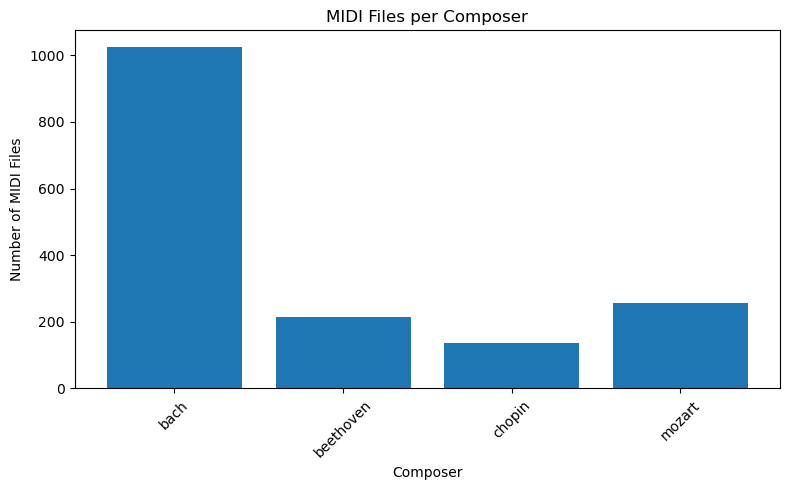

In [20]:
# Visualize the number of MIDI files for each composer.

plt.figure(figsize=(8, 5))

plt.bar(
    composer_counts.index,
    composer_counts.values
)

plt.title("MIDI Files per Composer")
plt.xlabel("Composer")
plt.ylabel("Number of MIDI Files")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. MIDI File Validation

Each selected MIDI file is checked before it is included in preprocessing. A usable MIDI file must:

- Open successfully with PrettyMIDI
- Contain at least one non-drum instrument
- Contain at least one pitched musical note

Drum tracks are excluded because they do not contain the melodic pitch information required for composer classification.

In [23]:
def validate_midi_file(file_path):
    """
    Check whether a MIDI file can be used for feature extraction.

    Parameters
    ----------
    file_path : str
        Complete path to the MIDI file.

    Returns
    -------
    dict
        Validation status and basic MIDI statistics.
    """
    try:
        midi_data = pretty_midi.PrettyMIDI(file_path)

        # Retain only non-drum instruments.
        non_drum_instruments = [
            instrument
            for instrument in midi_data.instruments
            if not instrument.is_drum
        ]

        # Count pitched notes across all non-drum instruments.
        number_of_notes = sum(
            len(instrument.notes)
            for instrument in non_drum_instruments
        )

        valid_midi = (
            len(non_drum_instruments) > 0
            and number_of_notes > 0
        )

        return {
            "valid_midi": valid_midi,
            "number_of_instruments": len(non_drum_instruments),
            "number_of_notes": number_of_notes,
            "duration_seconds": float(midi_data.get_end_time()),
            "error_message": None
        }

    except Exception as error:
        return {
            "valid_midi": False,
            "number_of_instruments": 0,
            "number_of_notes": 0,
            "duration_seconds": 0.0,
            "error_message": str(error)
        }

In [25]:
# Validate every MIDI file in the selected dataset.

validation_records = []

for index, row in inventory_df.iterrows():
    validation_result = validate_midi_file(
        row["file_path"]
    )

    validation_result["file_path"] = row["file_path"]
    validation_records.append(validation_result)

    if (index + 1) % 100 == 0:
        print(
            f"Validated {index + 1} of "
            f"{len(inventory_df)} files."
        )

validation_df = pd.DataFrame(validation_records)

# Combine validation results with the original inventory.
inventory_df = inventory_df.merge(
    validation_df,
    on="file_path",
    how="left"
)

print("MIDI validation completed.")

Validated 100 of 1630 files.
Validated 200 of 1630 files.
Validated 300 of 1630 files.
Validated 400 of 1630 files.
Validated 500 of 1630 files.
Validated 600 of 1630 files.
Validated 700 of 1630 files.
Validated 800 of 1630 files.
Validated 900 of 1630 files.
Validated 1000 of 1630 files.
Validated 1100 of 1630 files.
Validated 1200 of 1630 files.
Validated 1300 of 1630 files.
Validated 1400 of 1630 files.
Validated 1500 of 1630 files.
Validated 1600 of 1630 files.
MIDI validation completed.


## 4.1 Remove Unusable MIDI Files

Unreadable files and files without pitched notes are removed before the dataset is divided into training, validation, and testing sets.

In [28]:
# Separate usable and unusable MIDI files.

clean_inventory_df = inventory_df[
    inventory_df["valid_midi"]
].copy()

clean_inventory_df.reset_index(
    drop=True,
    inplace=True
)

problem_files_df = inventory_df[
    ~inventory_df["valid_midi"]
].copy()

print("Original MIDI files:", len(inventory_df))
print("Valid MIDI files:", len(clean_inventory_df))
print("Removed MIDI files:", len(problem_files_df))

if not problem_files_df.empty:
    display(
        problem_files_df[
            [
                "composer",
                "file_name",
                "error_message"
            ]
        ]
    )

Original MIDI files: 1630
Valid MIDI files: 1628
Removed MIDI files: 2


,composer,file_name,error_message
1028,beethoven,Anhang 14-3.mid,Could not decode key with 3 flats and mode 255
1494,mozart,K281 Piano Sonata n03 3mov.mid,Could not decode key with 2 flats and mode 2


# 5. Train, Validation, and Test Split

The valid compositions are divided into three subsets:

- 70% training
- 15% validation
- 15% testing

Stratified splitting is used so that each subset contains a proportional number of files from Bach, Beethoven, Chopin, and Mozart.

The original files are split before data augmentation. This prevents an original composition from appearing in one subset while an augmented version of the same composition appears in another subset.

In [31]:
# Create the 70% training set and a temporary 30% evaluation set.

train_inventory_df, temporary_inventory_df = train_test_split(
    clean_inventory_df,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=clean_inventory_df["composer"]
)

# Divide the temporary set equally into validation and testing sets.
dev_inventory_df, test_inventory_df = train_test_split(
    temporary_inventory_df,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=temporary_inventory_df["composer"]
)

# Create independent copies before adding split labels.
train_inventory_df = train_inventory_df.copy()
dev_inventory_df = dev_inventory_df.copy()
test_inventory_df = test_inventory_df.copy()

train_inventory_df["split"] = "train"
dev_inventory_df["split"] = "dev"
test_inventory_df["split"] = "test"

# Reset row indexes.
train_inventory_df.reset_index(drop=True, inplace=True)
dev_inventory_df.reset_index(drop=True, inplace=True)
test_inventory_df.reset_index(drop=True, inplace=True)

print("Training files:", len(train_inventory_df))
print("Validation files:", len(dev_inventory_df))
print("Testing files:", len(test_inventory_df))

Training files: 1139
Validation files: 244
Testing files: 245


## 5.1 Verify the Split Distribution

The distribution of composers is checked after splitting to confirm that every subset contains all four classes.

In [34]:
# Combine split records for distribution analysis.

split_inventory_df = pd.concat(
    [
        train_inventory_df,
        dev_inventory_df,
        test_inventory_df
    ],
    ignore_index=True
)

split_distribution = (
    split_inventory_df
    .groupby(["composer", "split"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=[
            "bach",
            "beethoven",
            "chopin",
            "mozart"
        ],
        columns=[
            "train",
            "dev",
            "test"
        ],
        fill_value=0
    )
)

split_distribution["total"] = (
    split_distribution.sum(axis=1)
)

display(split_distribution)

split,train,dev,test,total
composer,,,,
bach,717,153,154,1024
beethoven,148,32,32,212
chopin,95,21,20,136
mozart,179,38,39,256


# 6. Data Preprocessing and Feature Extraction

Each MIDI composition is converted into an ordered sequence of musical note events.

The following features are extracted:

1. **Pitch:** MIDI pitch value of the note
2. **Duration:** Length of the note in seconds
3. **Velocity:** Strength or intensity of the note
4. **Time Shift:** Time between the current note onset and the previous note onset
5. **Tempo:** Tempo active when the note begins
6. **Chord Size:** Number of notes beginning at approximately the same time
7. **Chord Span:** Distance between the lowest and highest pitches in the chord

Chord size and chord span provide information about simultaneous notes and harmonic structure. A single note has a chord size of one and a chord span of zero.

In [37]:
# Define the order of features in each extracted event.

FEATURE_NAMES = [
    "pitch",
    "duration",
    "velocity",
    "time_shift",
    "tempo",
    "chord_size",
    "chord_span"
]

NUMBER_OF_FEATURES = len(FEATURE_NAMES)

print("Extracted features:")
print(FEATURE_NAMES)

print("\nNumber of features per event:")
print(NUMBER_OF_FEATURES)

Extracted features:
['pitch', 'duration', 'velocity', 'time_shift', 'tempo', 'chord_size', 'chord_span']

Number of features per event:
7


In [39]:
def get_tempo_at_time(
    note_start,
    tempo_times,
    tempo_values
):
    """
    Return the tempo active at a specific note starting time.
    """
    if len(tempo_values) == 0:
        return 120.0

    tempo_index = np.searchsorted(
        tempo_times,
        note_start,
        side="right"
    ) - 1

    tempo_index = max(tempo_index, 0)

    return float(tempo_values[tempo_index])

In [41]:
def calculate_chord_information(notes, onset_precision=3):
    """
    Calculate chord size and pitch span for simultaneous notes.

    Notes with starting times that are equal after rounding are
    treated as belonging to the same chord.

    Parameters
    ----------
    notes : list of dict
        Extracted note information.
    onset_precision : int
        Number of decimal places used to group note onsets.

    Returns
    -------
    dict
        Chord information indexed by rounded note onset.
    """
    onset_groups = defaultdict(list)

    for note in notes:
        rounded_onset = round(
            note["start"],
            onset_precision
        )

        onset_groups[rounded_onset].append(
            note["pitch"]
        )

    chord_information = {}

    for onset, pitches in onset_groups.items():
        chord_size = len(pitches)

        chord_span = (
            max(pitches) - min(pitches)
            if chord_size > 1
            else 0
        )

        chord_information[onset] = {
            "chord_size": chord_size,
            "chord_span": chord_span
        }

    return chord_information

In [43]:
def extract_midi_sequence(
    file_path,
    pitch_shift=0
):
    """
    Convert one MIDI composition into a numerical event sequence.

    Parameters
    ----------
    file_path : str
        Complete path to the MIDI file.
    pitch_shift : int, default=0
        Number of semitones used for pitch-transposition
        augmentation.

    Returns
    -------
    numpy.ndarray
        Musical event sequence with seven features.
    """
    midi_data = pretty_midi.PrettyMIDI(file_path)

    # Retrieve tempo changes from the MIDI file.
    tempo_times, tempo_values = (
        midi_data.get_tempo_changes()
    )

    notes = []

    # Collect notes from every non-drum instrument.
    for instrument in midi_data.instruments:
        if instrument.is_drum:
            continue

        for note in instrument.notes:
            shifted_pitch = note.pitch + pitch_shift

            # Retain only valid MIDI pitch values.
            if 0 <= shifted_pitch <= 127:
                notes.append({
                    "pitch": int(shifted_pitch),
                    "start": float(note.start),
                    "end": float(note.end),
                    "velocity": int(note.velocity)
                })

    # Sort notes by starting time and then by pitch.
    notes.sort(
        key=lambda item: (
            item["start"],
            item["pitch"]
        )
    )

    # Determine which notes begin together as chords.
    chord_information = calculate_chord_information(
        notes
    )

    sequence = []
    previous_start = 0.0

    for note in notes:
        duration = max(
            note["end"] - note["start"],
            0.0
        )

        time_shift = max(
            note["start"] - previous_start,
            0.0
        )

        tempo = get_tempo_at_time(
            note_start=note["start"],
            tempo_times=tempo_times,
            tempo_values=tempo_values
        )

        rounded_onset = round(
            note["start"],
            3
        )

        chord_size = chord_information[
            rounded_onset
        ]["chord_size"]

        chord_span = chord_information[
            rounded_onset
        ]["chord_span"]

        sequence.append([
            float(note["pitch"]),
            float(duration),
            float(note["velocity"]),
            float(time_shift),
            float(tempo),
            float(chord_size),
            float(chord_span)
        ])

        previous_start = note["start"]

    return np.asarray(
        sequence,
        dtype=np.float32
    )

## 6.1 Test Feature Extraction

One valid MIDI composition is processed before the complete dataset to confirm that all seven musical features are extracted correctly.

In [46]:
# Select one valid training file.

sample_file_path = train_inventory_df.iloc[0][
    "file_path"
]

sample_sequence = extract_midi_sequence(
    file_path=sample_file_path,
    pitch_shift=0
)

print("Sample file:")
print(sample_file_path)

print("\nSample sequence shape:")
print(sample_sequence.shape)

display(
    pd.DataFrame(
        sample_sequence[:10],
        columns=FEATURE_NAMES
    )
)

Sample file:
/Users/zinaothman/Desktop/archive/midiclassics/Bach/Bwv001- 400 Chorales/039000b_.mid

Sample sequence shape:
(430, 7)


,pitch,duration,velocity,time_shift,tempo,chord_size,chord_span
0,60.0,0.545454,96.0,1.090908,110.000107,4.0,12.0
1,64.0,0.545454,96.0,0.000000,110.000107,4.0,12.0
2,67.0,0.545454,96.0,0.000000,110.000107,4.0,12.0
3,72.0,0.545454,96.0,0.000000,110.000107,4.0,12.0
4,57.0,1.090908,96.0,0.545454,110.000107,4.0,15.0
5,64.0,0.545454,96.0,0.000000,110.000107,4.0,15.0
6,69.0,1.090908,96.0,0.000000,110.000107,4.0,15.0
7,72.0,1.090908,96.0,0.000000,110.000107,4.0,15.0
8,65.0,0.545454,96.0,0.545454,110.000107,1.0,0.0
9,52.0,0.545454,96.0,0.545454,110.000107,4.0,19.0


# 7. Data Augmentation

Pitch transposition is used to increase the diversity of the training set. This method moves the pitches of a composition upward or downward while preserving its rhythm, tempo, intervals, and overall musical structure.

Each original training composition is retained, and two additional versions are created:

- Two semitones lower
- Original pitch
- Two semitones higher

Augmentation is applied only to the training set. The validation and testing sets remain unchanged to provide an unbiased evaluation of the final models.

In [49]:
# Define the pitch-transposition settings.

TRAIN_PITCH_SHIFTS = [
    -2,
    0,
    2
]

# Validation and testing compositions remain unchanged.
EVALUATION_PITCH_SHIFTS = [
    0
]

print("Training pitch shifts:", TRAIN_PITCH_SHIFTS)
print("Evaluation pitch shifts:", EVALUATION_PITCH_SHIFTS)

Training pitch shifts: [-2, 0, 2]
Evaluation pitch shifts: [0]


In [51]:
def process_dataset_split(
    split_inventory,
    split_name,
    pitch_shifts
):
    """
    Extract sequences and labels from one dataset split.

    Parameters
    ----------
    split_inventory : pandas.DataFrame
        MIDI files belonging to one dataset split.
    split_name : str
        Name of the dataset split.
    pitch_shifts : list of int
        Transpositions applied to each composition.

    Returns
    -------
    tuple
        Sequences, text labels, metadata, and errors.
    """
    sequences = []
    text_labels = []
    metadata_records = []
    error_records = []

    total_operations = (
        len(split_inventory)
        * len(pitch_shifts)
    )

    completed_operations = 0

    for _, row in split_inventory.iterrows():
        for pitch_shift in pitch_shifts:
            try:
                sequence = extract_midi_sequence(
                    file_path=row["file_path"],
                    pitch_shift=pitch_shift
                )

                if len(sequence) == 0:
                    raise ValueError(
                        "No musical events were extracted."
                    )

                sequences.append(sequence)
                text_labels.append(row["composer"])

                metadata_records.append({
                    "split": split_name,
                    "composer": row["composer"],
                    "file_name": row["file_name"],
                    "file_path": row["file_path"],
                    "pitch_shift": pitch_shift,
                    "augmented": pitch_shift != 0,
                    "sequence_length": len(sequence)
                })

            except Exception as error:
                error_records.append({
                    "split": split_name,
                    "composer": row["composer"],
                    "file_name": row["file_name"],
                    "pitch_shift": pitch_shift,
                    "error_message": str(error)
                })

            completed_operations += 1

            if completed_operations % 100 == 0:
                print(
                    f"{split_name}: processed "
                    f"{completed_operations} of "
                    f"{total_operations} operations."
                )

    return (
        sequences,
        text_labels,
        metadata_records,
        error_records
    )

## 7.1 Process the Training Data

The training data is processed using the original files and the two pitch-transposed versions.

In [54]:
(
    train_sequences,
    train_text_labels,
    train_metadata,
    train_errors
) = process_dataset_split(
    split_inventory=train_inventory_df,
    split_name="train",
    pitch_shifts=TRAIN_PITCH_SHIFTS
)

print("Generated training sequences:", len(train_sequences))
print("Training processing errors:", len(train_errors))

train: processed 100 of 3417 operations.
train: processed 200 of 3417 operations.
train: processed 300 of 3417 operations.
train: processed 400 of 3417 operations.
train: processed 500 of 3417 operations.
train: processed 600 of 3417 operations.
train: processed 700 of 3417 operations.
train: processed 800 of 3417 operations.
train: processed 900 of 3417 operations.
train: processed 1000 of 3417 operations.
train: processed 1100 of 3417 operations.
train: processed 1200 of 3417 operations.
train: processed 1300 of 3417 operations.
train: processed 1400 of 3417 operations.
train: processed 1500 of 3417 operations.
train: processed 1600 of 3417 operations.
train: processed 1700 of 3417 operations.
train: processed 1800 of 3417 operations.
train: processed 1900 of 3417 operations.
train: processed 2000 of 3417 operations.
train: processed 2100 of 3417 operations.
train: processed 2200 of 3417 operations.
train: processed 2300 of 3417 operations.
train: processed 2400 of 3417 operations.
t

## 7.2 Process the Validation Data

The validation data is processed without augmentation.

In [56]:
(
    dev_sequences,
    dev_text_labels,
    dev_metadata,
    dev_errors
) = process_dataset_split(
    split_inventory=dev_inventory_df,
    split_name="dev",
    pitch_shifts=EVALUATION_PITCH_SHIFTS
)

print("Generated validation sequences:", len(dev_sequences))
print("Validation processing errors:", len(dev_errors))

dev: processed 100 of 244 operations.
dev: processed 200 of 244 operations.
Generated validation sequences: 244
Validation processing errors: 0


## 7.3 Process the Testing Data

The testing data is processed without augmentation.

In [58]:
(
    test_sequences,
    test_text_labels,
    test_metadata,
    test_errors
) = process_dataset_split(
    split_inventory=test_inventory_df,
    split_name="test",
    pitch_shifts=EVALUATION_PITCH_SHIFTS
)

print("Generated testing sequences:", len(test_sequences))
print("Testing processing errors:", len(test_errors))

test: processed 100 of 245 operations.
test: processed 200 of 245 operations.
Generated testing sequences: 245
Testing processing errors: 0


In [62]:
# Combine processing errors from all three subsets.

all_processing_errors = (
    train_errors
    + dev_errors
    + test_errors
)

processing_errors_df = pd.DataFrame(
    all_processing_errors
)

print(
    "Total feature-extraction errors:",
    len(processing_errors_df)
)

if not processing_errors_df.empty:
    display(processing_errors_df)

Total feature-extraction errors: 0


# 8. Composer Label Encoding

TensorFlow classification models require numerical target labels. The composer names are converted into integers using the following mapping:

- Bach: 0
- Beethoven: 1
- Chopin: 2
- Mozart: 3

The same mapping is applied to the training, validation, and testing subsets.

In [65]:
# Define the required composer label mapping explicitly.

composer_to_index = {
    "bach": 0,
    "beethoven": 1,
    "chopin": 2,
    "mozart": 3
}

index_to_composer = {
    index: composer
    for composer, index
    in composer_to_index.items()
}

print("Composer label mapping:")

for composer, index in composer_to_index.items():
    print(f"{composer}: {index}")

Composer label mapping:
bach: 0
beethoven: 1
chopin: 2
mozart: 3


In [67]:
def encode_composer_labels(
    text_labels,
    label_mapping
):
    """
    Convert composer names into integer labels.
    """
    unknown_labels = sorted(
        set(text_labels)
        - set(label_mapping.keys())
    )

    if unknown_labels:
        raise ValueError(
            f"Unknown composer labels found: {unknown_labels}"
        )

    return np.asarray(
        [
            label_mapping[label]
            for label in text_labels
        ],
        dtype=np.int32
    )


# Encode composer labels for all dataset subsets.
y_train = encode_composer_labels(
    train_text_labels,
    composer_to_index
)

y_dev = encode_composer_labels(
    dev_text_labels,
    composer_to_index
)

y_test = encode_composer_labels(
    test_text_labels,
    composer_to_index
)

print("Training labels shape:", y_train.shape)
print("Validation labels shape:", y_dev.shape)
print("Testing labels shape:", y_test.shape)

Training labels shape: (3417,)
Validation labels shape: (244,)
Testing labels shape: (245,)


# 9. Sequence Normalization and Padding

The MIDI compositions contain different numbers of musical events. TensorFlow models require input samples with consistent dimensions.

The extracted numerical features are first normalized. The sequences are then padded or truncated to a fixed length using the TensorFlow/Keras `pad_sequences` function.

Post-padding adds zeros after the final musical event. Post-truncation removes events from the end of compositions that exceed the selected maximum sequence length.

## 9.1 Examine Training Sequence Lengths

The maximum sequence length is determined only from the training data. This prevents information from the validation or testing data from influencing preprocessing decisions.

In [71]:
# Calculate the length of every processed training sequence.

train_sequence_lengths = np.asarray(
    [
        len(sequence)
        for sequence in train_sequences
    ]
)

sequence_length_summary = (
    pd.Series(train_sequence_lengths)
    .describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .to_frame(
        name="training_sequence_length"
    )
)

display(sequence_length_summary)

,training_sequence_length
count,3417.000000
mean,3209.338016
std,4951.071924
min,83.000000
50%,1145.000000
75%,3967.000000
90%,8871.400000
95%,13063.400000
99%,21885.000000
max,46897.000000


The training dataset was analyzed to determine an appropriate maximum sequence length for padding. The initial estimate was based on the 95th percentile of the training sequence lengths. To keep memory usage and computational cost manageable during model training, the sequence length was capped at 2,000 musical events. Sequences shorter than 2,000 events are padded with zeros, while longer sequences are truncated after the first 2,000 events. This approach provides consistent input dimensions while maintaining efficient preprocessing and training.

In [74]:
# Select a practical sequence length based on the training data and an upper length cap.

SEQUENCE_PERCENTILE = 95
SEQUENCE_LENGTH_CAP = 2000

percentile_sequence_length = int(
    np.percentile(
        train_sequence_lengths,
        SEQUENCE_PERCENTILE
    )
)

MAX_SEQUENCE_LENGTH = min(
    percentile_sequence_length,
    SEQUENCE_LENGTH_CAP
)

MAX_SEQUENCE_LENGTH = max(
    MAX_SEQUENCE_LENGTH,
    1
)

print(
    "95th percentile sequence length:",
    percentile_sequence_length
)

print(
    "Maximum sequence length used:",
    MAX_SEQUENCE_LENGTH
)

95th percentile sequence length: 13063
Maximum sequence length used: 2000


Although the 95th percentile of the training sequences was 13,063 events, an upper limit of 2,000 events was intentionally applied to reduce computational requirements and produce fixed-length inputs for the deep learning models.

## 9.2 Normalize Musical Features

The extracted features use different numerical scales. The following transformations place them in approximately the same zero-to-one range:

- Pitch divided by 127
- Duration clipped at 10 seconds and divided by 10
- Velocity divided by 127
- Time shift clipped at 10 seconds and divided by 10
- Tempo clipped at 300 BPM and divided by 300
- Chord size clipped at 20 notes and divided by 20
- Chord span divided by 127

In [78]:
def normalize_sequence(sequence):
    """
    Normalize the seven musical features in one sequence.

    Feature order:
    pitch, duration, velocity, time shift, tempo,
    chord size, chord span
    """
    normalized_sequence = sequence.astype(
        np.float32
    ).copy()

    # Normalize pitch.
    normalized_sequence[:, 0] = (
        np.clip(
            normalized_sequence[:, 0],
            0,
            127
        )
        / 127.0
    )

    # Normalize note duration.
    normalized_sequence[:, 1] = (
        np.clip(
            normalized_sequence[:, 1],
            0,
            10
        )
        / 10.0
    )

    # Normalize note velocity.
    normalized_sequence[:, 2] = (
        np.clip(
            normalized_sequence[:, 2],
            0,
            127
        )
        / 127.0
    )

    # Normalize time shift.
    normalized_sequence[:, 3] = (
        np.clip(
            normalized_sequence[:, 3],
            0,
            10
        )
        / 10.0
    )

    # Normalize tempo.
    normalized_sequence[:, 4] = (
        np.clip(
            normalized_sequence[:, 4],
            0,
            300
        )
        / 300.0
    )

    # Normalize chord size.
    normalized_sequence[:, 5] = (
        np.clip(
            normalized_sequence[:, 5],
            0,
            20
        )
        / 20.0
    )

    # Normalize chord span.
    normalized_sequence[:, 6] = (
        np.clip(
            normalized_sequence[:, 6],
            0,
            127
        )
        / 127.0
    )

    return normalized_sequence

In [80]:
# Normalize all extracted musical sequences.

normalized_train_sequences = [
    normalize_sequence(sequence)
    for sequence in train_sequences
]

normalized_dev_sequences = [
    normalize_sequence(sequence)
    for sequence in dev_sequences
]

normalized_test_sequences = [
    normalize_sequence(sequence)
    for sequence in test_sequences
]

print("All sequences were normalized successfully.")

All sequences were normalized successfully.


## 9.3 Apply TensorFlow/Keras Padding

The normalized sequences are converted into fixed-length, three-dimensional arrays:

`number of compositions × maximum sequence length × number of features`

In [83]:
# Pad and truncate the sequences using TensorFlow/Keras.

X_train = pad_sequences(
    normalized_train_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    dtype="float32",
    padding="post",
    truncating="post",
    value=0.0
)

X_dev = pad_sequences(
    normalized_dev_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    dtype="float32",
    padding="post",
    truncating="post",
    value=0.0
)

X_test = pad_sequences(
    normalized_test_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    dtype="float32",
    padding="post",
    truncating="post",
    value=0.0
)

print("Training sequence shape:", X_train.shape)
print("Validation sequence shape:", X_dev.shape)
print("Testing sequence shape:", X_test.shape)

Training sequence shape: (3417, 2000, 7)
Validation sequence shape: (244, 2000, 7)
Testing sequence shape: (245, 2000, 7)


In [85]:
# Confirm that each sequence has one matching composer label.

assert X_train.shape[0] == y_train.shape[0]
assert X_dev.shape[0] == y_dev.shape[0]
assert X_test.shape[0] == y_test.shape[0]

# Confirm that all sequences contain seven features.
assert X_train.shape[2] == NUMBER_OF_FEATURES
assert X_dev.shape[2] == NUMBER_OF_FEATURES
assert X_test.shape[2] == NUMBER_OF_FEATURES

print("All sequences and labels are correctly aligned.")

All sequences and labels are correctly aligned.


# 10. TensorFlow Dataset Preparation

TensorFlow datasets are created from the processed arrays to confirm that the data can be passed directly into the LSTM and CNN models.

The training dataset is shuffled. The validation and testing datasets remain in their existing order.

In [88]:
# Define the batch size used to test TensorFlow compatibility.

BATCH_SIZE = 32

train_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        (X_train, y_train)
    )
    .shuffle(
        buffer_size=len(X_train),
        seed=RANDOM_SEED,
        reshuffle_each_iteration=True
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

dev_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        (X_dev, y_dev)
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        (X_test, y_test)
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("TensorFlow datasets created successfully.")

TensorFlow datasets created successfully.


In [90]:
# Inspect one batch from the TensorFlow training dataset.

for sequence_batch, label_batch in train_dataset.take(1):
    print(
        "Sequence batch shape:",
        sequence_batch.shape
    )

    print(
        "Label batch shape:",
        label_batch.shape
    )

    print(
        "Sequence data type:",
        sequence_batch.dtype
    )

    print(
        "Label data type:",
        label_batch.dtype
    )

Sequence batch shape: (32, 2000, 7)
Label batch shape: (32,)
Sequence data type: <dtype: 'float32'>
Label data type: <dtype: 'int32'>


2026-07-21 21:49:51.190463: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


# 11. Save the Processed Data

The TensorFlow-ready sequences, numerical composer labels, metadata, label mapping, and preprocessing configuration are saved for the LSTM and CNN model-development stages.

In [93]:
# Save the processed sequence and label arrays.

np.save(
    OUTPUT_DIR / "X_train.npy",
    X_train
)

np.save(
    OUTPUT_DIR / "y_train.npy",
    y_train
)

np.save(
    OUTPUT_DIR / "X_dev.npy",
    X_dev
)

np.save(
    OUTPUT_DIR / "y_dev.npy",
    y_dev
)

np.save(
    OUTPUT_DIR / "X_test.npy",
    X_test
)

np.save(
    OUTPUT_DIR / "y_test.npy",
    y_test
)

print("Processed sequence and label arrays were saved.")

Processed sequence and label arrays were saved.


In [95]:
# Save the composer-to-integer label mapping.

with open(
    OUTPUT_DIR / "composer_labels.json",
    "w",
    encoding="utf-8"
) as label_file:
    json.dump(
        composer_to_index,
        label_file,
        indent=4
    )

print("Composer label mapping was saved.")

Composer label mapping was saved.


In [97]:
# Save the preprocessing configuration.

processing_configuration = {
    "framework": "TensorFlow",
    "selected_composers": [
        "bach",
        "beethoven",
        "chopin",
        "mozart"
    ],
    "data_split": {
        "training": 0.70,
        "validation": 0.15,
        "testing": 0.15
    },
    "feature_names": FEATURE_NAMES,
    "number_of_features": NUMBER_OF_FEATURES,
    "maximum_sequence_length": MAX_SEQUENCE_LENGTH,
    "sequence_percentile": SEQUENCE_PERCENTILE,
    "sequence_length_cap": SEQUENCE_LENGTH_CAP,
    "training_pitch_shifts": TRAIN_PITCH_SHIFTS,
    "evaluation_pitch_shifts": EVALUATION_PITCH_SHIFTS,
    "padding": "post",
    "truncating": "post",
    "padding_value": 0.0,
    "batch_size": BATCH_SIZE
}

with open(
    OUTPUT_DIR / "processing_configuration.json",
    "w",
    encoding="utf-8"
) as configuration_file:
    json.dump(
        processing_configuration,
        configuration_file,
        indent=4
    )

print("Preprocessing configuration was saved.")

Preprocessing configuration was saved.


In [99]:
# Combine metadata from all processed sequences.

all_sequence_metadata = (
    train_metadata
    + dev_metadata
    + test_metadata
)

sequence_metadata_df = pd.DataFrame(
    all_sequence_metadata
)

# Add the numerical composer labels.
sequence_metadata_df["composer_index"] = (
    sequence_metadata_df["composer"]
    .map(composer_to_index)
)

# Save the sequence metadata.
sequence_metadata_df.to_csv(
    OUTPUT_DIR / "sequence_metadata.csv",
    index=False
)

# Save the original split inventory.
split_inventory_df.to_csv(
    OUTPUT_DIR / "dataset_split_inventory.csv",
    index=False
)

# Save feature-extraction errors when they exist.
if not processing_errors_df.empty:
    processing_errors_df.to_csv(
        OUTPUT_DIR / "processing_errors.csv",
        index=False
    )

print("Sequence metadata and split inventory were saved.")

display(sequence_metadata_df.head())

Sequence metadata and split inventory were saved.


,split,composer,file_name,file_path,pitch_shift,augmented,sequence_length,composer_index
0,train,bach,039000b_.mid,/Users/zinaothman/Desktop/archive/midiclassics...,-2,True,430,0
1,train,bach,039000b_.mid,/Users/zinaothman/Desktop/archive/midiclassics...,0,False,430,0
2,train,bach,039000b_.mid,/Users/zinaothman/Desktop/archive/midiclassics...,2,True,430,0
3,train,bach,024864b6.mid,/Users/zinaothman/Desktop/archive/midiclassics...,-2,True,3587,0
4,train,bach,024864b6.mid,/Users/zinaothman/Desktop/archive/midiclassics...,0,False,3587,0


# 12. Final Validation

The saved arrays are loaded again to confirm that the processed files are complete and ready for use by the TensorFlow LSTM and CNN models.

In [102]:
# Reload all saved sequence and label arrays.

saved_X_train = np.load(
    OUTPUT_DIR / "X_train.npy"
)

saved_y_train = np.load(
    OUTPUT_DIR / "y_train.npy"
)

saved_X_dev = np.load(
    OUTPUT_DIR / "X_dev.npy"
)

saved_y_dev = np.load(
    OUTPUT_DIR / "y_dev.npy"
)

saved_X_test = np.load(
    OUTPUT_DIR / "X_test.npy"
)

saved_y_test = np.load(
    OUTPUT_DIR / "y_test.npy"
)

print("Saved arrays loaded successfully.")

Saved arrays loaded successfully.


In [104]:
# Verify sequence and label alignment.

assert saved_X_train.shape[0] == saved_y_train.shape[0]
assert saved_X_dev.shape[0] == saved_y_dev.shape[0]
assert saved_X_test.shape[0] == saved_y_test.shape[0]

# Verify sequence dimensions.
assert saved_X_train.shape[1] == MAX_SEQUENCE_LENGTH
assert saved_X_dev.shape[1] == MAX_SEQUENCE_LENGTH
assert saved_X_test.shape[1] == MAX_SEQUENCE_LENGTH

# Verify feature dimensions.
assert saved_X_train.shape[2] == NUMBER_OF_FEATURES
assert saved_X_dev.shape[2] == NUMBER_OF_FEATURES
assert saved_X_test.shape[2] == NUMBER_OF_FEATURES

# Verify that all feature values are finite.
assert np.isfinite(saved_X_train).all()
assert np.isfinite(saved_X_dev).all()
assert np.isfinite(saved_X_test).all()

# Verify that normalized feature values remain in the expected range.
assert saved_X_train.min() >= 0.0
assert saved_X_train.max() <= 1.0

assert saved_X_dev.min() >= 0.0
assert saved_X_dev.max() <= 1.0

assert saved_X_test.min() >= 0.0
assert saved_X_test.max() <= 1.0

# Verify composer label values.
assert saved_y_train.min() >= 0
assert saved_y_train.max() <= 3

assert saved_y_dev.min() >= 0
assert saved_y_dev.max() <= 3

assert saved_y_test.min() >= 0
assert saved_y_test.max() <= 3

print("All final validation checks passed.")

All final validation checks passed.


In [105]:
# Display the final processed dataset summary.

final_dataset_summary = pd.DataFrame({
    "dataset_split": [
        "Training",
        "Validation",
        "Testing"
    ],
    "number_of_sequences": [
        len(saved_X_train),
        len(saved_X_dev),
        len(saved_X_test)
    ],
    "sequence_length": [
        saved_X_train.shape[1],
        saved_X_dev.shape[1],
        saved_X_test.shape[1]
    ],
    "features_per_event": [
        saved_X_train.shape[2],
        saved_X_dev.shape[2],
        saved_X_test.shape[2]
    ],
    "number_of_classes": [
        len(np.unique(saved_y_train)),
        len(np.unique(saved_y_dev)),
        len(np.unique(saved_y_test))
    ]
})

display(final_dataset_summary)

print("Feature order:")
print(FEATURE_NAMES)

print("\nComposer label mapping:")
print(composer_to_index)

print("\nProcessed files saved in:")
print(OUTPUT_DIR)

,dataset_split,number_of_sequences,sequence_length,features_per_event,number_of_classes
0,Training,3417,2000,7,4
1,Validation,244,2000,7,4
2,Testing,245,2000,7,4


Feature order:
['pitch', 'duration', 'velocity', 'time_shift', 'tempo', 'chord_size', 'chord_span']

Composer label mapping:
{'bach': 0, 'beethoven': 1, 'chopin': 2, 'mozart': 3}

Processed files saved in:
/Users/zinaothman/Desktop/composer_classification_processed


# 13. Data Preparation Summary

The preprocessing pipeline successfully prepared the MIDI dataset for deep learning by validating the input files, applying data augmentation to the training set, extracting musical features, encoding composer labels, and normalizing the feature values. TensorFlow/Keras padding and truncation were applied to create fixed-length input sequences of 2,000 musical events. Sequences shorter than 2,000 events were padded with zeros, while longer sequences were truncated after the first 2,000 events. This ensured consistent input dimensions for the LSTM and CNN models while keeping memory usage and computational requirements manageable. The processed datasets, metadata, and configuration files were saved and validated, providing a reproducible, model-ready dataset for the subsequent training and evaluation stages of the project.

Dataset Limitation
The dataset is imbalanced, with Bach containing substantially more compositions than Beethoven, Chopin, and Mozart. Stratified train, validation, and test splits were used to preserve the original class distribution across each dataset. While no balancing techniques were applied during preprocessing, the LSTM and CNN models may benefit from strategies such as class weighting or other imbalance-aware methods during training to reduce potential bias toward the majority class.